In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import seaborn as sns

sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)
matplotlib.rcParams.update({
    'figure.figsize': (4.5, 3.5),
    'figure.dpi': 120,
})


In [6]:
# ── 데이터 로드 ──────────────────────────────────────────────────────────
_HERE = os.path.dirname(os.path.abspath('__file__'))  # notebook 위치
CSV_PATH = os.path.join(_HERE, 'combined_results.csv')

df_all = pd.read_csv(CSV_PATH)
df = df_all[df_all['ratio'] < 1.0]  # ratio=1.0 제외

# Oracle: unseen data ratio=1.0, seen_ratio=1.0
oracle_val = df_all[(df_all['ratio'] == 1.0) & (df_all['seen_ratio'] == 1.0)]['unseen_reg'].mean()
print(f'shape: {df.shape}')
df.head()


shape: (320, 43)


,ratio,seen_ratio,game,unseen_games,seen_acc,unseen_acc,seen_reg,unseen_reg,seen_avg_diff,unseen_avg_diff,...,zelda_enum_1,zelda_enum_2,zelda_enum_3,zelda_enum_4,run_id,run_name,run_state,cfg_unseen_games,cfg_seen_ratio,cfg_seed
0,0.00,0.05,all,pkzd,1.000000,1.0,0.086346,0.178667,0.080087,0.188563,...,0.071999,0.364710,0.261629,0.252805,2n9fgt2f,clipdec-unseen-game-all_unseen-pkzd_sr-0.05_md...,finished,pkzd,0.05,0
1,0.01,0.05,all,pkzd,1.000000,1.0,0.085275,0.137816,0.081149,0.142040,...,0.063821,0.142149,0.208205,0.124002,2n9fgt2f,clipdec-unseen-game-all_unseen-pkzd_sr-0.05_md...,finished,pkzd,0.05,0
2,0.03,0.05,all,pkzd,1.000000,1.0,0.088408,0.135571,0.084338,0.139725,...,0.065636,0.127577,0.209803,0.138910,2n9fgt2f,clipdec-unseen-game-all_unseen-pkzd_sr-0.05_md...,finished,pkzd,0.05,0
3,0.05,0.05,all,pkzd,0.999667,1.0,0.087418,0.122932,0.083227,0.127182,...,0.052579,0.127784,0.149471,0.138545,2n9fgt2f,clipdec-unseen-game-all_unseen-pkzd_sr-0.05_md...,finished,pkzd,0.05,0
4,0.10,0.05,all,pkzd,0.999667,1.0,0.084161,0.111973,0.080719,0.114862,...,0.042761,0.124154,0.096003,0.128723,2n9fgt2f,clipdec-unseen-game-all_unseen-pkzd_sr-0.05_md...,finished,pkzd,0.05,0


In [7]:
# ── unseen_games 별로 평균 집계 ───────────────────────────────────────────
# 같은 (ratio, seen_ratio) 조합의 여러 unseen_games 를 평균
agg_df = (
    df.groupby(['ratio', 'seen_ratio'])
    .agg(unseen_reg_mean=('unseen_reg', 'mean'),
         unseen_reg_std=('unseen_reg', 'std'),
         count=('unseen_reg', 'count'))
    .reset_index()
)
agg_df['unseen_reg_se'] = agg_df['unseen_reg_std'] / np.sqrt(agg_df['count'])
agg_df


,ratio,seen_ratio,unseen_reg_mean,unseen_reg_std,count,unseen_reg_se
0,0.00,0.00,0.257852,0.016575,10,0.005242
1,0.00,0.05,0.187336,0.024111,10,0.007625
2,0.00,0.10,0.190471,0.024355,10,0.007702
3,0.00,1.00,0.176976,0.022597,10,0.007146
4,0.01,0.00,0.125848,0.026810,10,0.008478
5,0.01,0.05,0.133238,0.021535,10,0.006810
6,0.01,0.10,0.135315,0.020542,10,0.006496
7,0.01,1.00,0.129320,0.026654,10,0.008429
8,0.03,0.00,0.110265,0.024254,10,0.007670
9,0.03,0.05,0.113358,0.027163,10,0.008590


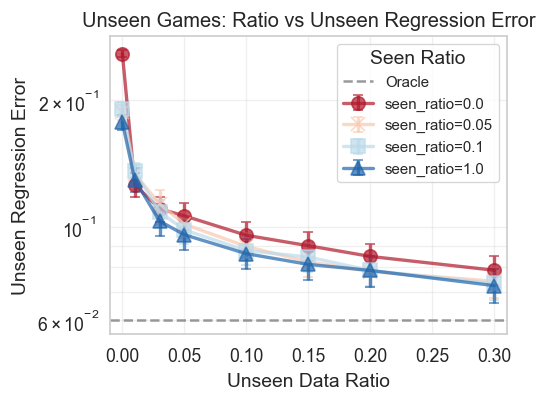

In [13]:
# ── 플롯: ratio vs unseen_reg (seen_ratio 별 색/마커) ────────────────────
palette = sns.color_palette('deep', 4)
seen_ratios = sorted(agg_df['seen_ratio'].unique())
cmap = plt.cm.RdBu
palette = [cmap(x) for x in np.linspace(0.1, 0.9, len(seen_ratios))]  # 양 끝 진하게
COLORS = dict(zip(seen_ratios, palette))
MARKERS = {0.0: 'o', 0.1: 's', 0.5: 'D', 1.0: '^'}

fig, ax = plt.subplots()

for sr in sorted(agg_df['seen_ratio'].unique()):
    sub = agg_df[agg_df['seen_ratio'] == sr].sort_values('ratio')
    ax.errorbar(
        sub['ratio'], sub['unseen_reg_mean'],
        yerr=sub['unseen_reg_se'],
        label=f'seen_ratio={sr}',
        color=COLORS.get(sr, 'gray'),
        marker=MARKERS.get(sr, 'x'),
        markersize=8,
        linewidth=2,
        capsize=3,
        alpha=0.7,
    )

ax.axhline(y=oracle_val, color='gray', linestyle='--', linewidth=1.5, alpha=0.8, label='Oracle')

ax.set_yscale('log')
ax.set_xlabel('Unseen Data Ratio')
ax.set_ylabel('Unseen Regression Error')
ax.set_title('Unseen Games: Ratio vs Unseen Regression Error')
# set title font size
ax.title.set_fontsize(12)
ax.legend(title='Seen Ratio', fontsize=9)
ax.set_xlim(-0.01, 0.31)
# ax.set_ylim(0.003, 0.12)
# ax.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
# ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
# ax.set_yticks([0.005, 0.01, 0.02, 0.05, 0.1])
# ax.get_yaxis().set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.3f'))
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(os.path.join(_HERE, 'ratio_vs_unseen_reg.png'), bbox_inches='tight', facecolor='white')
plt.show()
